<a href="https://colab.research.google.com/github/badaraaliouguindo/heart-disease-predictor/blob/main/notebooks/03_SHAP_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation et imports

In [1]:
!pip install shap -q

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

shap.initjs()

# Rechargement et préparation

In [2]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)

cat_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Remettre les noms de colonnes après scaling
X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X.columns)

model = XGBClassifier(n_estimators=100, max_depth=4,
                      learning_rate=0.1, random_state=42,
                      eval_metric='logloss')
model.fit(X_train_sc, y_train)
print("Modèle prêt !")

Modèle prêt !


# Calcul des valeurs SHAP

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sc)

print("Valeurs SHAP calculées !")
print("Shape :", shap_values.shape)

Valeurs SHAP calculées !
Shape : (61, 23)


# Graphique 1 : importance globale des features

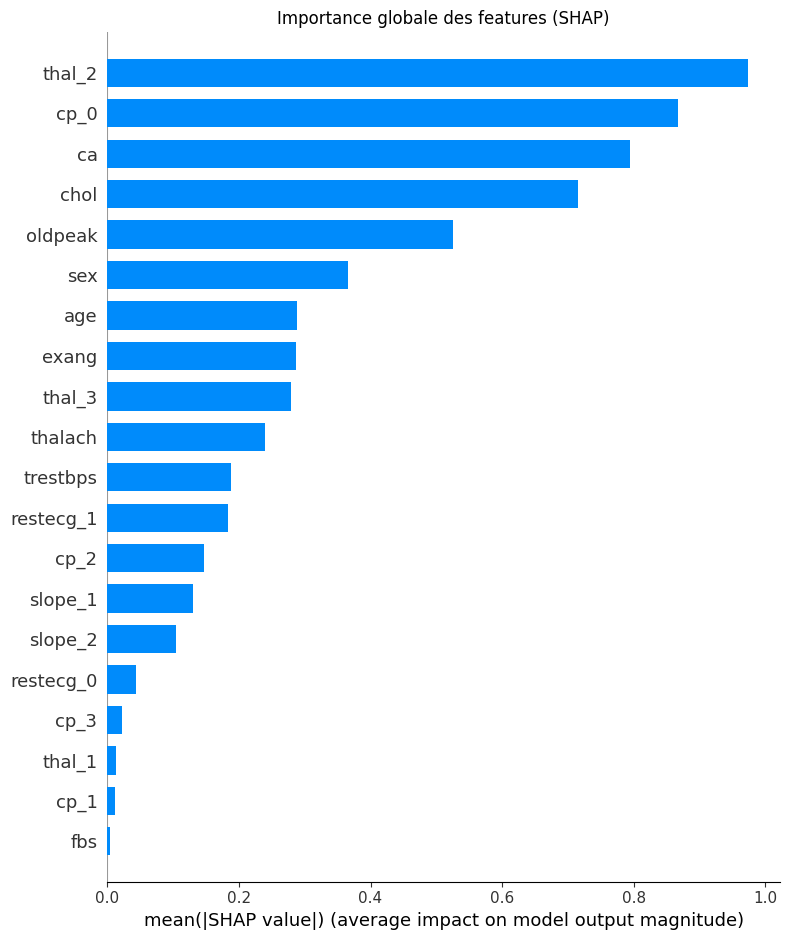

In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sc, plot_type="bar",
                  show=False)
plt.title("Importance globale des features (SHAP)")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# Graphique 2 : impact et direction de chaque feature

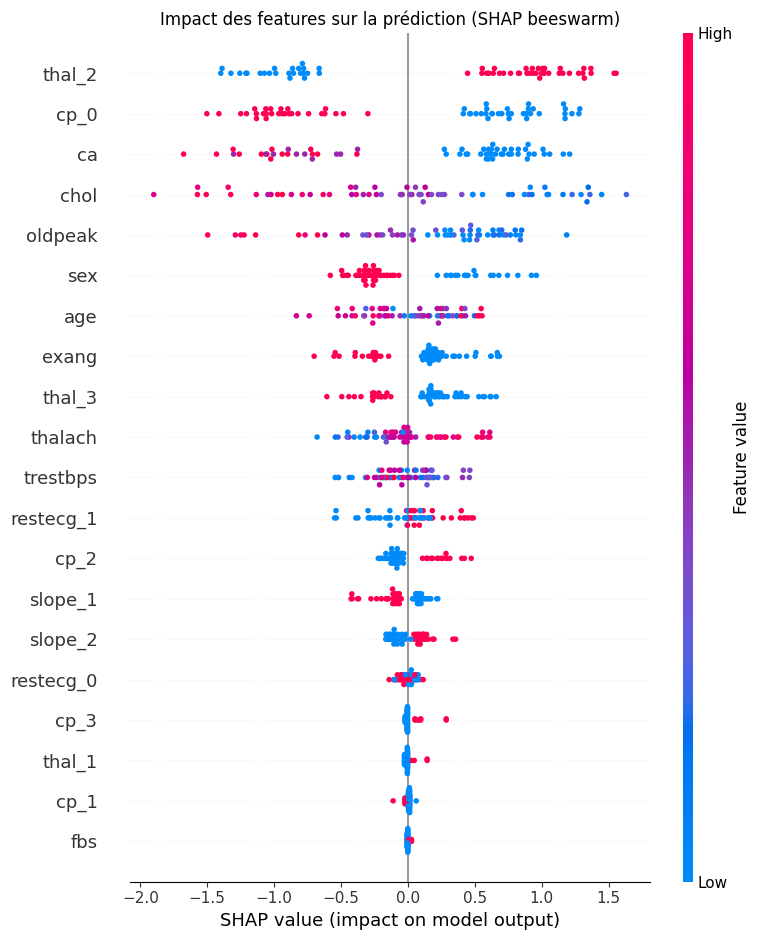

In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sc, show=False)
plt.title("Impact des features sur la prédiction (SHAP beeswarm)")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

#  Graphique 3 : explication d'un patient individuel

Patient 0 :
  Prédiction : Pas de maladie
  Réalité    : Pas de maladie


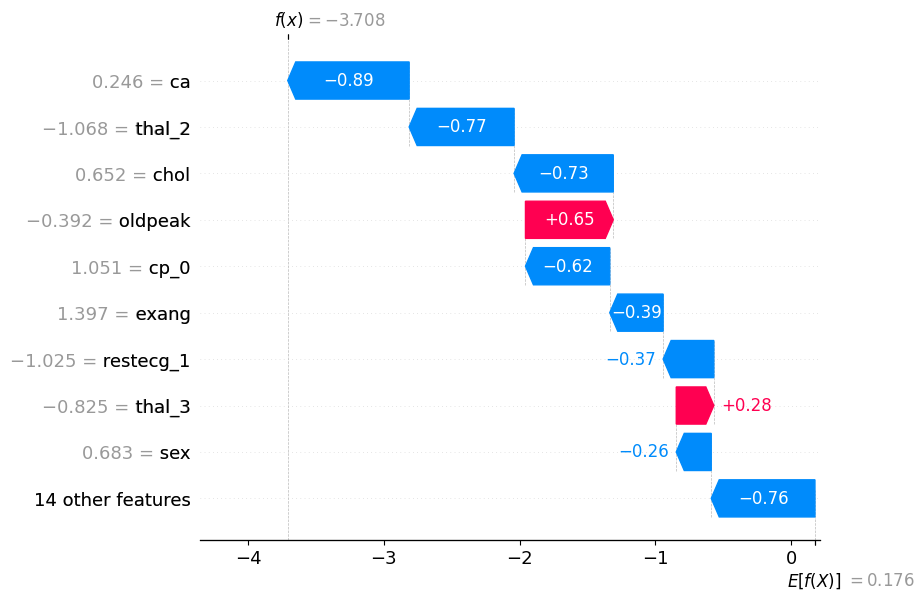

In [6]:
# On explique la prédiction pour le patient numéro 0 du test set
patient_idx = 0
prediction  = model.predict(X_test_sc)[patient_idx]
realite     = y_test.values[patient_idx]

print(f"Patient {patient_idx} :")
print(f"  Prédiction : {'Maladie cardiaque' if prediction == 1 else 'Pas de maladie'}")
print(f"  Réalité    : {'Maladie cardiaque' if realite == 1 else 'Pas de maladie'}")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[patient_idx],
        base_values   = explainer.expected_value,
        data          = X_test_sc.iloc[patient_idx],
        feature_names = X.columns.tolist()
    )
)

# Sauvegarder le modèle et le scaler

In [8]:
import joblib

joblib.dump(model,  'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Modèle, scaler et features sauvegardés !")

Modèle, scaler et features sauvegardés !
